# Final Project - Development and Evaluation of Baseline, Enhanced and Hierarchical Agentic Retrieval Augmented Generation (RAG) Architectures for Improving Large Language Models




### Question answering using HotpotQA dataset

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 115.2 MB/s eta 0:00:00


In [ ]:
!pip install datasets

In [ ]:
# Basic libraries
import os
import re
import numpy as np
import pandas as pd

# PyTorch
import torch

# Hugging Face dataset utilities
from datasets import load_dataset, concatenate_datasets

# Transformer models and tokenizers
from transformers import AutoTokenizer, AutoModel, AutoModelForCausalLM

# Vector database
import faiss

# progress bars
from tqdm import tqdm

###Load HotpotQA question, answer, context, and supporting-fact fields

In [ ]:
from datasets import load_dataset

dataset_HotpotQA = load_dataset("hotpot_qa", "distractor")
print(dataset_HotpotQA)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

distractor/train-00000-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/train-00001-of-00002.parquet:   0%|          | 0.00/166M [00:00<?, ?B/s]

distractor/validation-00000-of-00001.par(…):   0%|          | 0.00/27.5M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/90447 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/7405 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'],
        num_rows: 90447
    })
    validation: Dataset({
        features: ['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'],
        num_rows: 7405
    })
})


## Data Split
###Train / validation / test workflow

In [ ]:
from datasets import load_dataset, concatenate_datasets

# Combine original train and validation
full_dataset = concatenate_datasets([dataset_HotpotQA["train"], dataset_HotpotQA["validation"]])

# First split: 80% train, 20% temp
split1 = full_dataset.train_test_split(test_size=0.2, seed=42)

train_data = split1["train"]

# Second split: split remaining 20% into 10% val + 10% test
split2 = split1["test"].train_test_split(test_size=0.5, seed=42)

val_data = split2["train"]
test_data = split2["test"]

print(len(train_data), len(val_data), len(test_data))

78281 9785 9786


In [ ]:
print(len(full_dataset))

97852


#Baseline RAG Preprocessing

- Manual preprocessing: cleaning, flattening, chunking
- Model tokenizer preprocessing = subword tokenization automatically handled by the pretrained tokenizer

###Flatten HotpotQA context

In [ ]:
sample = train_data[0]

titles = sample["context"]["title"]
sentences = sample["context"]["sentences"]

context_text = ""

for title, sent_list in zip(titles, sentences):
    context_text += title + ": " + " ".join(sent_list) + "\n\n"

print("Question:", sample["question"])
print("\nAnswer:", sample["answer"])
print("\nContext:\n", context_text[:1000])

Question: What town in Troms county Norway, is home to the Kroken Church?

Answer: Tromso

Context:
 Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, wooden church was built in 1829.  The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.  This church seats about 220 people.

Troms Police District: Troms Police District in Norway includes seventeen municipalities in Troms county with approximately 122,000 people and is headquartered in Tromsø.  Troms Police Distrikt covers Troms county except Central Hålogaland.

Movik: Movik is a village in the municipality of Tromsø in Troms county, Norway.  It's located along the Tromsøysundet on the mainland part of the municipality.  The villa

In [ ]:
print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Context:", context_text)

Question: What town in Troms county Norway, is home to the Kroken Church?
Answer: Tromso
Context: Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, wooden church was built in 1829.  The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.  This church seats about 220 people.

Troms Police District: Troms Police District in Norway includes seventeen municipalities in Troms county with approximately 122,000 people and is headquartered in Tromsø.  Troms Police Distrikt covers Troms county except Central Hålogaland.

Movik: Movik is a village in the municipality of Tromsø in Troms county, Norway.  It's located along the Tromsøysundet on the mainland part of the municipality.  The village 

In [ ]:
sample = train_data[0]

print(type(sample))
print(sample.keys())
print(type(sample["context"]))
print(sample["context"])

<class 'dict'>
dict_keys(['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context'])
<class 'dict'>
{'title': ['Bardu Church', 'Troms Police District', 'Movik', 'Kroken Church', 'Altevatnet', 'Lyngen (fjord)', 'Tromsø', 'Kroken, Troms', 'Troms County Municipality', 'Jiehkkevárri'], 'sentences': [['Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.', ' It is located in the village of Setermoen.', ' The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.', ' The octagonal, white, wooden church was built in 1829.', ' The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.', ' This church seats about 220 people.'], ['Troms Police District in Norway includes seventeen municipalities in Troms county with approximately 122,000 people and is headquartered in Tromsø.', ' Troms Police Distrikt covers Troms count

###Function - converts each HotpotQA example into document chunks

###Converted each document into retrieval-ready chunks

In [ ]:
def build_document_chunks(example):
    chunks = []

    titles = example["context"]["title"]
    sentences = example["context"]["sentences"]

    for title, sent_list in zip(titles, sentences):
        chunk_text = title + ": " + " ".join(sent_list)
        chunks.append(chunk_text)

    return {
        "question": example["question"],
        "answer": example["answer"],
        "chunks": chunks,
        "supporting_facts": example["supporting_facts"]
    }

In [ ]:
processed_sample = build_document_chunks(train_data[0])

print("Question:", processed_sample["question"])
print("Answer:", processed_sample["answer"])
print("Number of chunks:", len(processed_sample["chunks"]))
print("\nFirst chunk:\n", processed_sample["chunks"][0])

Question: What town in Troms county Norway, is home to the Kroken Church?
Answer: Tromso
Number of chunks: 10

First chunk:
 Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, wooden church was built in 1829.  The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.  This church seats about 220 people.


In [ ]:
train_processed = train_data.map(build_document_chunks)
val_processed = val_data.map(build_document_chunks)
test_processed = test_data.map(build_document_chunks)

Map:   0%|          | 0/78281 [00:00<?, ? examples/s]

Map:   0%|          | 0/9785 [00:00<?, ? examples/s]

Map:   0%|          | 0/9786 [00:00<?, ? examples/s]

In [ ]:
sample_processed = train_processed[0]

print(sample_processed.keys())
print("Question:", sample_processed["question"])
print("Answer:", sample_processed["answer"])
print("Number of chunks:", len(sample_processed["chunks"]))
print("\nFirst chunk:\n", sample_processed["chunks"][0])
print("\nSupporting facts:\n", sample_processed["supporting_facts"])

dict_keys(['id', 'question', 'answer', 'type', 'level', 'supporting_facts', 'context', 'chunks'])
Question: What town in Troms county Norway, is home to the Kroken Church?
Answer: Tromso
Number of chunks: 10

First chunk:
 Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, wooden church was built in 1829.  The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.  This church seats about 220 people.

Supporting facts:
 {'title': ['Kroken Church', 'Tromsø', 'Tromsø'], 'sent_id': [0, 0, 2]}


In [ ]:
print(type(train_processed[0]["chunks"]))
print(len(train_processed[0]["chunks"]))
print(train_processed[0]["chunks"][0][:300])

<class 'list'>
10
Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, woo


##Load BGE-M3 and test embedding on a small sample of chunks
Its tokenizer handles the tokenization needed before embedding

In [ ]:


model_name = "BAAI/bge-m3"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 1024, padding_idx=1)
    (token_type_embeddings): Embedding(1, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(8194, 1024, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-23): 24 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-05, elementw

In [ ]:
sample_chunks = train_processed[0]["chunks"][:3]

inputs = tokenizer(
    sample_chunks,
    padding=True,
    truncation=True,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.last_hidden_state.shape)

torch.Size([3, 132, 1024])


#set up the Baseline RAG pipeline

- embed chunks with BGE-M3
- store embeddings in FAISS
- embed question
- retrieve top-k chunks
- send retrieved context and question to Qwen3
- generate answer

#Testing purpose using small subset

###convert each chunk into BGE-M3 embeddings.


- Create a small embedding function and test it
- Apply it on the dataset

In [ ]:
def mean_pooling(last_hidden_state, attention_mask):
    mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
    summed = torch.sum(last_hidden_state * mask, dim=1)
    counts = torch.clamp(mask.sum(dim=1), min=1e-9)
    return summed / counts


def encode_texts(texts, tokenizer, model, device, max_length=512):
    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    embeddings = mean_pooling(outputs.last_hidden_state, inputs["attention_mask"])
    embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)

    return embeddings.cpu().numpy()

In [ ]:
sample_chunks = train_processed[0]["chunks"][:2]
sample_embeddings = encode_texts(sample_chunks, tokenizer, model, device)

print(sample_embeddings.shape)
print(sample_embeddings[0][:10])

(2, 1024)
[ 0.03887042  0.01975752 -0.03267401  0.0083246   0.03149011 -0.0479775
  0.00499456  0.0009722  -0.00615     0.01783405]


###Prepare chunk records for FAISS. Since each example has multiple chunks

- Need to flatten them into a list like:

   - chunk text
   - question ID / example ID
   - chunk index









In [ ]:
train_chunk_records = []

for example in train_processed:
    ex_id = example["id"]
    question = example["question"]
    answer = example["answer"]

    for chunk_idx, chunk_text in enumerate(example["chunks"]):
        train_chunk_records.append({
            "id": ex_id,
            "question": question,
            "answer": answer,
            "chunk_idx": chunk_idx,
            "chunk_text": chunk_text
        })

print("Total training chunks:", len(train_chunk_records))
print(train_chunk_records[0])

Total training chunks: 778651
{'id': '5a765e165542992d0ec060bf', 'question': 'What town in Troms county Norway, is home to the Kroken Church?', 'answer': 'Tromso', 'chunk_idx': 0, 'chunk_text': 'Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, wooden church was built in 1829.  The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.  This church seats about 220 people.'}


###Store embeddings in FAISS

In [ ]:
# Test on a small subset first
subset_chunks = [record["chunk_text"] for record in train_chunk_records[:1000]]

all_embeddings = []

batch_size = 16

for start_idx in tqdm(range(0, len(subset_chunks), batch_size)):
    batch_chunks = subset_chunks[start_idx:start_idx + batch_size]

    batch_embeddings = encode_texts(
        batch_chunks,
        tokenizer,
        model,
        device
    )

    all_embeddings.append(batch_embeddings)

# Combine into one array
all_embeddings = np.vstack(all_embeddings)

print(all_embeddings.shape)

100%|██████████| 63/63 [00:12<00:00,  5.08it/s]

(1000, 1024)


In [ ]:
# Create FAISS index
embedding_dim = all_embeddings.shape[1]

index = faiss.IndexFlatL2(embedding_dim)

# Add embeddings to the index
index.add(all_embeddings)

print("Number of indexed chunks:", index.ntotal)

Number of indexed chunks: 1000


###Question embedding + retrieval test.

In [ ]:
# Example question
query = train_processed[0]["question"]

# Encode the question
query_embedding = encode_texts([query], tokenizer, model, device)

print("Query embedding shape:", query_embedding.shape)

Query embedding shape: (1, 1024)


###Retrieve top-k chunks from FAISS (Facebook AI Similarity Search):

In [ ]:
k = 3

distances, indices = index.search(query_embedding, k)

print("Retrieved indices:", indices)
print("Distances:", distances)

Retrieved indices: [[3 7 6]]
Distances: [[0.2901461  0.31363714 0.41405374]]


In [ ]:
for rank, idx in enumerate(indices[0], 1):
    print(f"\nRank {rank} | Chunk index: {idx}\n")
    print(train_chunk_records[idx]["chunk_text"][:1000])


Rank 1 | Chunk index: 3

Kroken Church: Kroken Church (Norwegian: "Kroken kirke" ) is a parish church in the municipality of Tromsø in Troms county, Norway.  It is located in the Kroken borough in the city of Tromsø.  The church is part of the Kroken parish in the Tromsø arch-deanery in the Diocese of Nord-Hålogaland.  The brown, rectangular, brick building was constructed in 2006.  The church seats about 600 people.

Rank 2 | Chunk index: 7

Kroken, Troms: Kroken is a part of the city of Tromsø in the municipality of Tromsø in Troms county, Norway.  The district is located along Tromsøysundet (the Tromsø strait) on the mainland of Norway.  It sits across the strait from the city centre of Tromsø on the island of Tromsøya.  The Tromsdalen area of the city of Tromsø lies about 4 km to the south and the village of Movik lies about 3 km to the north.

Rank 3 | Chunk index: 6

Tromsø: Tromsø (] ; Northern Sami: "Romsa" ; Finnish: "Tromssa" ; Kven: "Tromssa" ) is a city and municipality in

###combine the retrieved chunks into one context

In [ ]:
retrieved_context = "\n\n".join(
    [train_chunk_records[idx]["chunk_text"] for idx in indices[0]]
)

print(retrieved_context)

Kroken Church: Kroken Church (Norwegian: "Kroken kirke" ) is a parish church in the municipality of Tromsø in Troms county, Norway.  It is located in the Kroken borough in the city of Tromsø.  The church is part of the Kroken parish in the Tromsø arch-deanery in the Diocese of Nord-Hålogaland.  The brown, rectangular, brick building was constructed in 2006.  The church seats about 600 people.

Kroken, Troms: Kroken is a part of the city of Tromsø in the municipality of Tromsø in Troms county, Norway.  The district is located along Tromsøysundet (the Tromsø strait) on the mainland of Norway.  It sits across the strait from the city centre of Tromsø on the island of Tromsøya.  The Tromsdalen area of the city of Tromsø lies about 4 km to the south and the village of Movik lies about 3 km to the north.

Tromsø: Tromsø (] ; Northern Sami: "Romsa" ; Finnish: "Tromssa" ; Kven: "Tromssa" ) is a city and municipality in Troms county, Norway.  The administrative centre of the municipality is the

#Load Qwen tokenizer and model

In [ ]:


qwen_model_name = "Qwen/Qwen3-4B-Instruct-2507"

qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_name)
qwen_model = AutoModelForCausalLM.from_pretrained(
    qwen_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

###Encoder / retriever

- preprocess chunks
- embed with BGE-M3
- store in FAISS


#Training-Phase Baseline RAG Retrieval Setup (Full Dataset):

- Full dataset chunking (778K chunks)
- BGE-M3 embeddings
- FAISS index built on full chunk corpus




In [ ]:
import re
import string

def normalize_text(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = " ".join(text.split())
    return text

In [ ]:
full_train_chunk_records = []

for example in train_processed:
    ex_id = example["id"]
    question = example["question"]
    answer = example["answer"]

    for chunk_idx, chunk_text in enumerate(example["chunks"]):
        full_train_chunk_records.append({
            "id": ex_id,
            "question": question,
            "answer": answer,
            "chunk_idx": chunk_idx,
            "chunk_text": chunk_text
        })

print("Total full training chunks:", len(full_train_chunk_records))
print(full_train_chunk_records[0])

Total full training chunks: 778651
{'id': '5a765e165542992d0ec060bf', 'question': 'What town in Troms county Norway, is home to the Kroken Church?', 'answer': 'Tromso', 'chunk_idx': 0, 'chunk_text': 'Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, wooden church was built in 1829.  The architect Ole Olsen Lundberg designed the church, built as a copy of the larger Tynset Church in Hedmark county.  This church seats about 220 people.'}


In [ ]:
full_chunk_texts = [record["chunk_text"] for record in full_train_chunk_records]

print("Number of full chunk texts:", len(full_chunk_texts))
print(full_chunk_texts[0][:300])

Number of full chunk texts: 778651
Bardu Church: Bardu Church (Norwegian: "Bardu kirke" ) is a parish church in the municipality of Bardu in Troms county, Norway.  It is located in the village of Setermoen.  The church is part of the Bardu parish in the Indre Troms deanery in the Diocese of Nord-Hålogaland.  The octagonal, white, woo


In [ ]:
full_embeddings = []

batch_size = 64

for start_idx in tqdm(range(0, len(full_chunk_texts), batch_size)):
    batch_chunks = full_chunk_texts[start_idx:start_idx + batch_size]

    batch_embeddings = encode_texts(
        batch_chunks,
        tokenizer,
        model,
        device
    )

    full_embeddings.append(batch_embeddings)

full_embeddings = np.vstack(full_embeddings)

print("Full embedding shape:", full_embeddings.shape)

100%|██████████| 12167/12167 [3:10:16<00:00,  1.07it/s]


Full embedding shape: (778651, 1024)


In [ ]:
embedding_dim = full_embeddings.shape[1]

index_full = faiss.IndexFlatL2(embedding_dim)
index_full.add(full_embeddings)

In [ ]:
faiss.write_index(index_full, "index_full.faiss")
np.save("full_chunk_embeddings.npy", full_embeddings)

import pickle
with open("full_train_chunk_records.pkl", "wb") as f:
    pickle.dump(full_train_chunk_records, f)

In [ ]:
from collections import Counter

def compute_em(prediction, ground_truth):
    return int(normalize_text(prediction) == normalize_text(ground_truth))

def compute_f1(prediction, ground_truth):
    pred_tokens = normalize_text(prediction).split()
    gold_tokens = normalize_text(ground_truth).split()

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return int(pred_tokens == gold_tokens)

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

In [ ]:
import matplotlib.pyplot as plt

def plot_em_f1_bar(em_score, f1_score, title="Baseline RAG Validation Performance"):
    metrics = ["EM", "F1"]
    values = [em_score, f1_score]

    plt.figure(figsize=(6, 4))
    plt.bar(metrics, values)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)

    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

    plt.show()

In [ ]:
def run_baseline_rag(question, index, chunk_records, tokenizer, model, device,
                     qwen_tokenizer, qwen_model, k=3, max_new_tokens=50, temperature=0.1):

    query_embedding = encode_texts([question], tokenizer, model, device)
    distances, indices = index.search(query_embedding, k)

    retrieved_chunks = [chunk_records[idx]["chunk_text"] for idx in indices[0]]
    retrieved_context = "\n\n".join(retrieved_chunks)

    prompt = f"""
Answer the question using only the retrieved context.

Return only the exact short answer phrase.
Do not explain.
Do not add dates, years, or extra words.

Context:
{retrieved_context}

Question:
{question}

Short answer:
"""

    inputs = qwen_tokenizer(prompt, return_tensors="pt").to(qwen_model.device)

    with torch.no_grad():
        output_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature
        )

    generated_answer = qwen_tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    return {
        "question": question,
        "retrieved_indices": indices[0],
        "retrieved_chunks": retrieved_chunks,
        "generated_answer": generated_answer
    }

In [ ]:
result = run_baseline_rag(
    question=val_data[0]["question"],
    index=index_full,
    chunk_records=full_train_chunk_records,
    tokenizer=tokenizer,
    model=model,
    device=device,
    qwen_tokenizer=qwen_tokenizer,
    qwen_model=qwen_model,
    k=3
)

In [ ]:
import re

pred = result["generated_answer"]

# clean prediction
pred = pred.strip().split("\n")[0].strip()
pred = re.sub(r"\(.*?\)", "", pred).strip()

print("Prediction:", pred)
print("Gold:", val_data[0]["answer"])
print("EM:", compute_em(pred, val_data[0]["answer"]))
print("F1:", compute_f1(pred, val_data[0]["answer"]))

Prediction: Femme Fatale
Gold: Femme Fatale
EM: 1
F1: 1.0


In [ ]:
import re

em_scores = []
f1_scores = []

for i in range(10):
    question = val_data[i]["question"]
    gold = val_data[i]["answer"]

    result = run_baseline_rag(
        question=question,
        index=index_full,
        chunk_records=full_train_chunk_records,
        tokenizer=tokenizer,
        model=model,
        device=device,
        qwen_tokenizer=qwen_tokenizer,
        qwen_model=qwen_model,
        k=3,
        temperature=0.1,
        max_new_tokens=50
    )

    pred = result["generated_answer"]
    pred = pred.strip().split("\n")[0].strip()
    pred = re.sub(r"\(.*?\)", "", pred).strip()

    em = compute_em(pred, gold)
    f1 = compute_f1(pred, gold)

    em_scores.append(em)
    f1_scores.append(f1)

    print(f"\nExample {i+1}")
    print("Prediction:", pred)
    print("Gold:", gold)
    print("EM:", em)
    print("F1:", f1)


avg_EM = sum(em_scores) / len(em_scores)
avg_F1 = sum(f1_scores) / len(f1_scores)

print("\nAverage EM:", avg_EM)
print("Average F1:", avg_F1)


Example 1
Prediction: Femme Fatale
Gold: Femme Fatale
EM: 1
F1: 1.0

Example 2
Prediction: The Great Escape.
Gold: "The Great Escape"
EM: 1
F1: 1.0

Example 3
Prediction: Don Warner.
Gold: Floyd Patterson
EM: 0
F1: 0.0

Example 4
Prediction: The provided context does not mention the Carabao Cup or any cup that Cambridge United participates in under that name. Therefore, the answer is: Not in the provided context.
Gold: EFL Cup
EM: 0
F1: 0.07407407407407407

Example 5
Prediction: 1972.
Gold: 1972
EM: 1
F1: 1.0

Example 6
Prediction: Housefull
Gold: Ankahee
EM: 0
F1: 0.0

Example 7
Prediction: Union College.
Gold: Frank L. Messa Rink
EM: 0
F1: 0.0

Example 8
Prediction: Excalibur Hotel and Casino.
Gold: Bellagio
EM: 0
F1: 0.0

Example 9
Prediction: German. The provided context does not mention Julia Görges or any semifinal match in the 2012 Dubai Tennis Championships. Therefore, the nationality of Julia Görges cannot be determined from the given information. The correct answer based on


In [ ]:
import matplotlib.pyplot as plt

def plot_em_f1_bar(em_score, f1_score, title="Baseline RAG Validation Performance"):
    metrics = ["EM", "F1"]
    values = [em_score, f1_score]

    plt.figure(figsize=(6, 4))
    plt.bar(metrics, values)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)

    for i, v in enumerate(values):
        plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

    plt.show()

The baseline results show that incorrect predictions are primarily due to missing or incorrect retrieved context rather than generation errors. This indicates that retrieval quality is a key limiting factor in the Baseline RAG model.

#Hyperparameter tuning setup:
Before fine-tuning, the Baseline RAG model with the pretrained Qwen generator is evaluated on the validation set, and key hyperparameters are tuned to establish a reliable baseline for later comparison.

- tune k

- tune temperature

- tune max_new_tokens

In [ ]:
import matplotlib.pyplot as plt

def plot_hyperparameter_bar(param_values, em_scores, f1_scores, param_name="k", title=None):
    x = range(len(param_values))
    width = 0.35

    if title is None:
        title = f"Hyperparameter Tuning: {param_name}"

    plt.figure(figsize=(8, 4))
    plt.bar([i - width/2 for i in x], em_scores, width=width, label="EM")
    plt.bar([i + width/2 for i in x], f1_scores, width=width, label="F1")

    plt.xticks(list(x), [str(v) for v in param_values])
    plt.ylim(0, 1)
    plt.xlabel(param_name)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()

    for i, v in enumerate(em_scores):
        plt.text(i - width/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

    for i, v in enumerate(f1_scores):
        plt.text(i + width/2, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

    plt.show()

#Evaluation Function for EM and F1 methods

In [ ]:
def evaluate_model(qwen_model, k=3, temperature=0.0, max_new_tokens=20, num_samples=10):

    em_scores = []
    f1_scores = []

    for example in val_data[:num_samples]:
        question = example["question"]
        gold = example["answer"]

        result = run_baseline_rag(
            question=question,
            index=index_full,
            chunk_records=full_train_chunk_records,
            tokenizer=tokenizer,
            model=model,
            device=device,
            qwen_tokenizer=qwen_tokenizer,
            qwen_model=qwen_model,
            k=k,
            temperature=temperature,
            max_new_tokens=max_new_tokens
        )

        pred = result["generated_answer"]

        # clean prediction
        pred = pred.strip().split("\n")[0].strip()
        pred = re.sub(r"\(.*?\)", "", pred).strip()

        em_scores.append(compute_em(pred, gold))
        f1_scores.append(compute_f1(pred, gold))

    avg_em = sum(em_scores) / len(em_scores)
    avg_f1 = sum(f1_scores) / len(f1_scores)

    return avg_em, avg_f1

In [ ]:
def run_baseline_rag(question, index, chunk_records, tokenizer, model, device,
                     qwen_tokenizer, qwen_model, k=3, max_new_tokens=50, temperature=0.1):

    # Encode query
    query_embedding = encode_texts([question], tokenizer, model, device)
    distances, indices = index.search(query_embedding, k)

    # Retrieve context
    retrieved_chunks = [chunk_records[idx]["chunk_text"] for idx in indices[0]]
    retrieved_context = "\n\n".join(retrieved_chunks)

    # Prompt
    prompt = f"""
Answer the question using only the retrieved context.

Return only the exact short answer phrase.
Do not explain.
Do not add dates, years, or extra words.

Context:
{retrieved_context}

Question:
{question}

Short answer:
"""

    # Tokenize
    inputs = qwen_tokenizer(prompt, return_tensors="pt").to(qwen_model.device)

    # Generate (FIXED PART)
    with torch.no_grad():
        if temperature == 0.0:
            output_ids = qwen_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False   # greedy decoding
            )
        else:
            output_ids = qwen_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=True
            )

    # Decode output
    generated_answer = qwen_tokenizer.decode(
        output_ids[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    ).strip()

    return {
        "question": question,
        "retrieved_indices": indices[0],
        "retrieved_chunks": retrieved_chunks,
        "generated_answer": generated_answer
    }

In [ ]:
k_values = [1, 3, 5]

em_scores_k = []
f1_scores_k = []

for k in k_values:
    avg_em, avg_f1 = evaluate_model(
        qwen_model=qwen_model,   # pretrained model
        k=k,
        temperature=0.0,
        max_new_tokens=20,
        num_samples=50
    )

    em_scores_k.append(avg_em)
    f1_scores_k.append(avg_f1)

    print(f"\nk = {k}")
    print("Average EM:", avg_em)
    print("Average F1:", avg_f1)

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



k = 1
Average EM: 0.18
Average F1: 0.24439482739482737

k = 3
Average EM: 0.2
Average F1: 0.26038013207982247

k = 5
Average EM: 0.2
Average F1: 0.2512142857142857


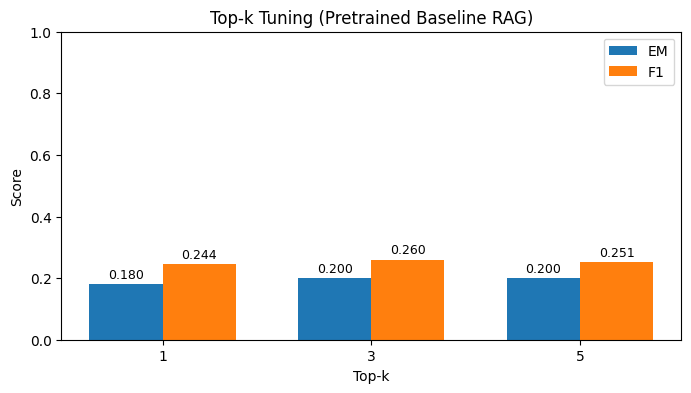

In [ ]:
plot_hyperparameter_bar(
    param_values=k_values,
    em_scores=em_scores_k,
    f1_scores=f1_scores_k,
    param_name="Top-k",
    title="Top-k Tuning (Pretrained Baseline RAG)"
)

In [ ]:
temperatures = [0.0, 0.1, 0.3]

em_scores_temp = []
f1_scores_temp = []

for temp in temperatures:
    avg_em, avg_f1 = evaluate_model(
        qwen_model=qwen_model,
        k=3,
        temperature=temp,
        max_new_tokens=20,
        num_samples=50
    )

    em_scores_temp.append(avg_em)
    f1_scores_temp.append(avg_f1)

    print(f"\nTemperature = {temp}")
    print("Average EM:", avg_em)
    print("Average F1:", avg_f1)


Temperature = 0.0
Average EM: 0.2
Average F1: 0.26038013207982247

Temperature = 0.1
Average EM: 0.2
Average F1: 0.2618280958807275

Temperature = 0.3
Average EM: 0.2
Average F1: 0.2635689865689866


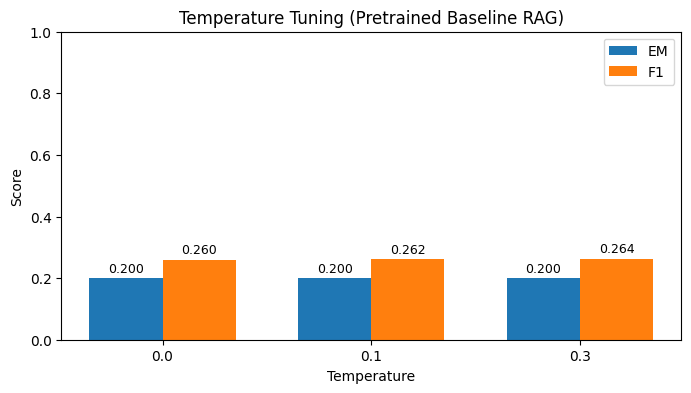

In [ ]:
plot_hyperparameter_bar(
    param_values=temperatures,
    em_scores=em_scores_temp,
    f1_scores=f1_scores_temp,
    param_name="Temperature",
    title="Temperature Tuning (Pretrained Baseline RAG)"
)

In [ ]:
max_tokens_list = [20, 50, 80]

em_scores_tokens = []
f1_scores_tokens = []

for max_tok in max_tokens_list:
    avg_em, avg_f1 = evaluate_model(
        qwen_model=qwen_model,
        k=3,
        temperature=0.3,
        max_new_tokens=max_tok,
        num_samples=50
    )

    em_scores_tokens.append(avg_em)
    f1_scores_tokens.append(avg_f1)

    print(f"\nMax tokens = {max_tok}")
    print("Average EM:", avg_em)
    print("Average F1:", avg_f1)


Max tokens = 20
Average EM: 0.2
Average F1: 0.2696300366300366

Max tokens = 50
Average EM: 0.18
Average F1: 0.24456271397447868

Max tokens = 80
Average EM: 0.18
Average F1: 0.23262161753590324


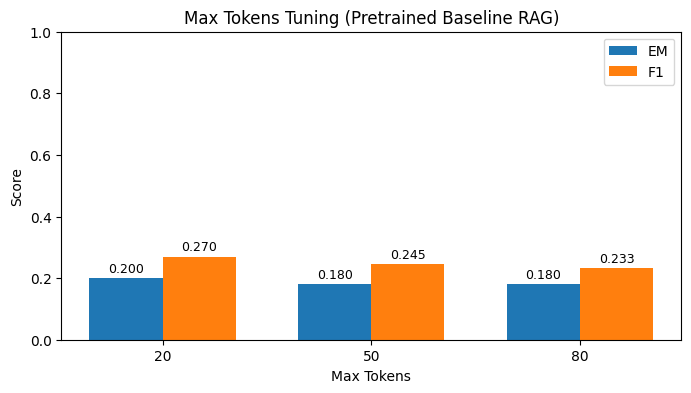

In [ ]:
plot_hyperparameter_bar(
    param_values=max_tokens_list,
    em_scores=em_scores_tokens,
    f1_scores=f1_scores_tokens,
    param_name="Max Tokens",
    title="Max Tokens Tuning (Pretrained Baseline RAG)"
)

#Hyperparameters - optimal values

Hyperparameters such as top-k retrieval, generation temperature, and maximum output length were tuned on the validation set using the pretrained Baseline RAG model. Based on empirical evaluation,
- Hyperparameter Tuning Summary (Pretrained Baseline RAG)
Top-k (Retrieval Depth):
Performance improves from k=1 to k=3 and then slightly drops at k=5.
 **Optimal: k = 3 (best balance of relevant context and noise)**

- Temperature (Generation Diversity):
Slight improvement as temperature increases.
**Optimal: temperature = 0.3 (highest F1 with stable EM)**

- Max Tokens (Output Length):
Longer outputs degrade performance due to verbosity/noise.
**Optimal: max_tokens = 20 (short, precise answers)**

#Fine-tuning the Pretrained Decoder model QWEN:

For fine-tuning in the RAG settings, the generator model (Qwen) is adapted using supervised fine-tuning (SFT) on HotpotQA training examples. This fine-tuned generator is intended to be used across all three RAG architectures (Baseline, Enhanced, and Hierarchical). Each training instance is converted into an instruction-style prompt containing only the supporting-fact documents as context, followed by the question, while the target output is the gold short answer. This design encourages the model to generate concise answer phrases rather than long explanatory sentences. Using only supporting-fact context provides cleaner supervision and helps the generator learn grounded question answering based on relevant evidence.

Fine-tuning method
Supervised Fine-Tuning (SFT)
Parameter-efficient tuning: LoRA
Goal: make Qwen return short, correct, context-grounded answers for HotpotQA

In [ ]:
def build_qwen_sft_example(example):
    titles = example["context"]["title"]
    sentences = example["context"]["sentences"]
    supporting_titles = set(example["supporting_facts"]["title"])

    supporting_chunks = []

    for title, sent_list in zip(titles, sentences):
        if title in supporting_titles:
            chunk_text = title + ": " + " ".join(sent_list)
            supporting_chunks.append(chunk_text)

    context_text = "\n\n".join(supporting_chunks)

    prompt = f"""Answer the question using only the provided context.

Return only the exact short answer phrase.
Do not explain.
Do not add dates, years, or extra words.

Context:
{context_text}

Question:
{example["question"]}

Short answer:
"""

    return {
        "prompt": prompt,
        "answer": example["answer"]
    }

In [ ]:
sft_train = train_data.map(build_qwen_sft_example)
sft_val = val_data.map(build_qwen_sft_example)

print(sft_train[0]["prompt"][:1200])
print("Answer:", sft_train[0]["answer"])

Map:   0%|          | 0/78281 [00:00<?, ? examples/s]

Map:   0%|          | 0/9785 [00:00<?, ? examples/s]

Answer the question using only the provided context.

Return only the exact short answer phrase.
Do not explain.
Do not add dates, years, or extra words.

Context:
Kroken Church: Kroken Church (Norwegian: "Kroken kirke" ) is a parish church in the municipality of Tromsø in Troms county, Norway.  It is located in the Kroken borough in the city of Tromsø.  The church is part of the Kroken parish in the Tromsø arch-deanery in the Diocese of Nord-Hålogaland.  The brown, rectangular, brick building was constructed in 2006.  The church seats about 600 people.

Tromsø: Tromsø (] ; Northern Sami: "Romsa" ; Finnish: "Tromssa" ; Kven: "Tromssa" ) is a city and municipality in Troms county, Norway.  The administrative centre of the municipality is the city of Tromsø.  Outside of Norway, "Tromso" and "Tromsö" are alternative spellings of the city.  Tromsø town has a population of 64,376 as of 1 January 2016.  The most populous town north of it is Alta, Norway, with a population of 14,272 (2013).



In [ ]:
def format_for_sft(example):
    text = example["prompt"] + example["answer"].strip()
    return {"text": text}

sft_train_text = sft_train.map(format_for_sft)
sft_val_text = sft_val.map(format_for_sft)

print(sft_train_text[0]["text"][:1200])

Map:   0%|          | 0/78281 [00:00<?, ? examples/s]

Map:   0%|          | 0/9785 [00:00<?, ? examples/s]

Answer the question using only the provided context.

Return only the exact short answer phrase.
Do not explain.
Do not add dates, years, or extra words.

Context:
Kroken Church: Kroken Church (Norwegian: "Kroken kirke" ) is a parish church in the municipality of Tromsø in Troms county, Norway.  It is located in the Kroken borough in the city of Tromsø.  The church is part of the Kroken parish in the Tromsø arch-deanery in the Diocese of Nord-Hålogaland.  The brown, rectangular, brick building was constructed in 2006.  The church seats about 600 people.

Tromsø: Tromsø (] ; Northern Sami: "Romsa" ; Finnish: "Tromssa" ; Kven: "Tromssa" ) is a city and municipality in Troms county, Norway.  The administrative centre of the municipality is the city of Tromsø.  Outside of Norway, "Tromso" and "Tromsö" are alternative spellings of the city.  Tromsø town has a population of 64,376 as of 1 January 2016.  The most populous town north of it is Alta, Norway, with a population of 14,272 (2013).



In [ ]:
!pip install -q peft trl bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 54.3 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, TrainingArguments
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

In [ ]:
qwen_model_name = "Qwen/Qwen3-4B-Instruct-2507"

qwen_tokenizer = AutoTokenizer.from_pretrained(qwen_model_name)

if qwen_tokenizer.pad_token is None:
    qwen_tokenizer.pad_token = qwen_tokenizer.eos_token

qwen_ft_model = AutoModelForCausalLM.from_pretrained(
    qwen_model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Tokenizer and model loaded.")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Tokenizer and model loaded.


In [ ]:
qwen_ft_model = prepare_model_for_kbit_training(qwen_ft_model)

In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

In [ ]:
qwen_ft_model = get_peft_model(qwen_ft_model, lora_config)
qwen_ft_model.print_trainable_parameters()

trainable params: 5,898,240 || all params: 4,028,366,336 || trainable%: 0.1464


In [ ]:
sft_train_text = sft_train_text.remove_columns(
    [c for c in sft_train_text.column_names if c != "text"]
)
sft_val_text = sft_val_text.remove_columns(
    [c for c in sft_val_text.column_names if c != "text"]
)

print(sft_train_text.column_names)
print(sft_val_text.column_names)
print(sft_train_text[0]["text"][:800])

['text']
['text']
Answer the question using only the provided context.

Return only the exact short answer phrase.
Do not explain.
Do not add dates, years, or extra words.

Context:
Kroken Church: Kroken Church (Norwegian: "Kroken kirke" ) is a parish church in the municipality of Tromsø in Troms county, Norway.  It is located in the Kroken borough in the city of Tromsø.  The church is part of the Kroken parish in the Tromsø arch-deanery in the Diocese of Nord-Hålogaland.  The brown, rectangular, brick building was constructed in 2006.  The church seats about 600 people.

Tromsø: Tromsø (] ; Northern Sami: "Romsa" ; Finnish: "Tromssa" ; Kven: "Tromssa" ) is a city and municipality in Troms county, Norway.  The administrative centre of the municipality is the city of Tromsø.  Outside of Norway, "Tromso" and 


In [ ]:
from trl import SFTTrainer, SFTConfig

In [ ]:
sft_config = SFTConfig(
    output_dir="qwen_hotpotqa_lora",
    num_train_epochs=1,
    learning_rate=2e-5,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    logging_steps=100,
    eval_strategy="steps",
    eval_steps=1000,
    save_strategy="steps",
    save_steps=1000,
    save_total_limit=2,
    load_best_model_at_end=True,
    dataset_text_field="text",
    packing=False,
    bf16=torch.cuda.is_available(),
    fp16=not torch.cuda.is_available(),
    report_to="none"
)

In [ ]:
trainer = SFTTrainer(
    model=qwen_ft_model,
    args=sft_config,
    train_dataset=sft_train_text,
    eval_dataset=sft_val_text,
    processing_class=qwen_tokenizer,
)

Adding EOS to train dataset:   0%|          | 0/78281 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/78281 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/9785 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/9785 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
1000,1.358902,1.350111
2000,1.350620,1.335853
3000,1.337446,1.329129
4000,1.315821,1.325100
5000,1.330832,1.322477
6000,1.330845,1.320580
7000,1.317027,1.319151
8000,1.324161,1.318104


Step,Training Loss,Validation Loss
1000,1.358902,1.350111
2000,1.350620,1.335853
3000,1.337446,1.329129
4000,1.315821,1.325100
5000,1.330832,1.322477
6000,1.330845,1.320580
7000,1.317027,1.319151
8000,1.324161,1.318104
9000,1.319071,1.317564


TrainOutput(global_step=9786, training_loss=1.3458483282978393, metrics={'train_runtime': 23298.5258, 'train_samples_per_second': 3.36, 'train_steps_per_second': 0.42, 'total_flos': 5.764203379643904e+17, 'train_loss': 1.3458483282978393})

##Evaluate the fine-tuned Qwen Baseline RAG on the validation set using the same optimal values from Hyperparameter tuning:
- k = 3
- temperature = 0.3
- max_new_tokens = 20

In [ ]:
ft_val_em, ft_val_f1 = evaluate_model(
    qwen_model=qwen_ft_model,
    k=3,
    temperature=0.3,
    max_new_tokens=20,
    num_samples=50
)

print("Fine-tuned Baseline RAG - Validation Set")
print("Average EM:", ft_val_em)
print("Average F1:", ft_val_f1)

Fine-tuned Baseline RAG - Validation Set
Average EM: 0.3
Average F1: 0.39057142857142857


In [ ]:
baseline_val_em, baseline_val_f1 = evaluate_model(
    qwen_model=qwen_model,
    k=3,
    temperature=0.3,
    max_new_tokens=20,
    num_samples=50
)

print("Baseline (Pretrained)")
print(baseline_val_em, baseline_val_f1)

Baseline (Pretrained)
0.2 0.25970344035049914


In [ ]:
import pandas as pd

validation_results = pd.DataFrame({
    "Model": ["Pretrained Baseline RAG", "Fine-tuned Baseline RAG"],
    "Dataset": ["Validation", "Validation"],
    "EM": [baseline_val_em, ft_val_em],
    "F1": [baseline_val_f1, ft_val_f1]
})

validation_results

,Model,Dataset,EM,F1
0,Pretrained Baseline RAG,Validation,0.2,0.259703
1,Fine-tuned Baseline RAG,Validation,0.3,0.390571


##Validation Comparison Plot - Pretrained Model vs Fine-tuned Model (SFT with LoRA)

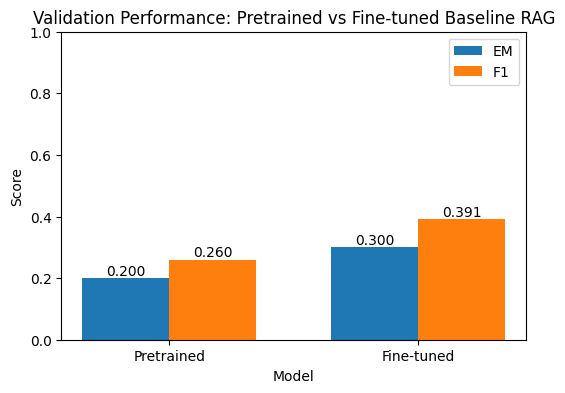

In [ ]:
import matplotlib.pyplot as plt

models = ["Pretrained", "Fine-tuned"]

em_values = [baseline_val_em, ft_val_em]
f1_values = [baseline_val_f1, ft_val_f1]

x = range(len(models))
width = 0.35

plt.figure(figsize=(6, 4))

# EM bars
plt.bar([i - width/2 for i in x], em_values, width=width, label="EM")

# F1 bars
plt.bar([i + width/2 for i in x], f1_values, width=width, label="F1")

plt.xticks(x, models)
plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Validation Performance: Pretrained vs Fine-tuned Baseline RAG")
plt.legend()

# Add values on bars
for i, v in enumerate(em_values):
    plt.text(i - width/2, v + 0.01, f"{v:.3f}", ha="center")

for i, v in enumerate(f1_values):
    plt.text(i + width/2, v + 0.01, f"{v:.3f}", ha="center")

plt.show()

#Evaluate on Test Set

In [ ]:
test_em, test_f1 = evaluate_model(
    qwen_model=qwen_ft_model,
    k=3,
    temperature=0.3,
    max_new_tokens=20,
    num_samples=150

print("Fine-tuned Baseline RAG - Test Set")
print("Average EM:", test_em)
print("Average F1:", test_f1)

Fine-tuned Baseline RAG - Test Set
Average EM: 0.3
Average F1: 0.3561371830783595


In [ ]:
test_results = pd.DataFrame({
    "Model": ["Fine-tuned Baseline RAG"],
    "Dataset": ["Test"],
    "EM": [test_em],
    "F1": [test_f1]
})

test_results

,Model,Dataset,EM,F1
0,Fine-tuned Baseline RAG,Test,0.3,0.356137


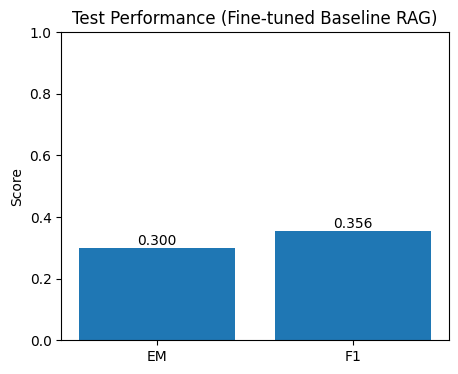

In [ ]:
import matplotlib.pyplot as plt

metrics = ["EM", "F1"]
values = [test_em, test_f1]

plt.figure(figsize=(5, 4))
plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Test Performance (Fine-tuned Baseline RAG)")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.show()

In [ ]:
plt.savefig("validation_comparison_plot.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.show()

In [ ]:
from google.colab import files
files.download("validation_comparison_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##Save everything and create zip (model, results, notebook)

In [ ]:
import os
import zipfile
import shutil
from google.colab import files

# 1. Save fine-tuned Qwen LoRA model
trainer.model.save_pretrained("qwen_hotpotqa_lora_final")
qwen_tokenizer.save_pretrained("qwen_hotpotqa_lora_final")

print("Saved model files:")
print(os.listdir("qwen_hotpotqa_lora_final"))

# 2. Save result tables
validation_results.to_csv("validation_results.csv", index=False)
test_results.to_csv("test_results.csv", index=False)

# 3. Zip fine-tuned model folder
shutil.make_archive(
    "qwen_hotpotqa_lora_final",
    "zip",
    "qwen_hotpotqa_lora_final"
)

# 4. Zip RAG retrieval artifacts
with zipfile.ZipFile("rag_data.zip", "w") as zipf:
    zipf.write("index_full.faiss")
    zipf.write("full_chunk_embeddings.npy")
    zipf.write("full_train_chunk_records.pkl")

# 5. Zip evaluation result files
with zipfile.ZipFile("baseline_rag_results.zip", "w") as zipf:
    zipf.write("validation_results.csv")
    zipf.write("test_results.csv")

# 6. Check final files
print("\nFinal files created:")
for file in [
    "qwen_hotpotqa_lora_final.zip",
    "rag_data.zip",
    "baseline_rag_results.zip"
]:
    print(file, "exists:", os.path.exists(file))

# 7. Download all important zip files
files.download("qwen_hotpotqa_lora_final.zip")
files.download("rag_data.zip")
files.download("baseline_rag_results.zip")

Saved model files:
['README.md', 'tokenizer.json', 'chat_template.jinja', 'tokenizer_config.json', 'adapter_model.safetensors', 'adapter_config.json']

Final files created:
qwen_hotpotqa_lora_final.zip exists: True
rag_data.zip exists: True
baseline_rag_results.zip exists: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("index_full.faiss")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("full_train_chunk_records.pkl")